Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1020.0..1020.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1020.0..1020.0].


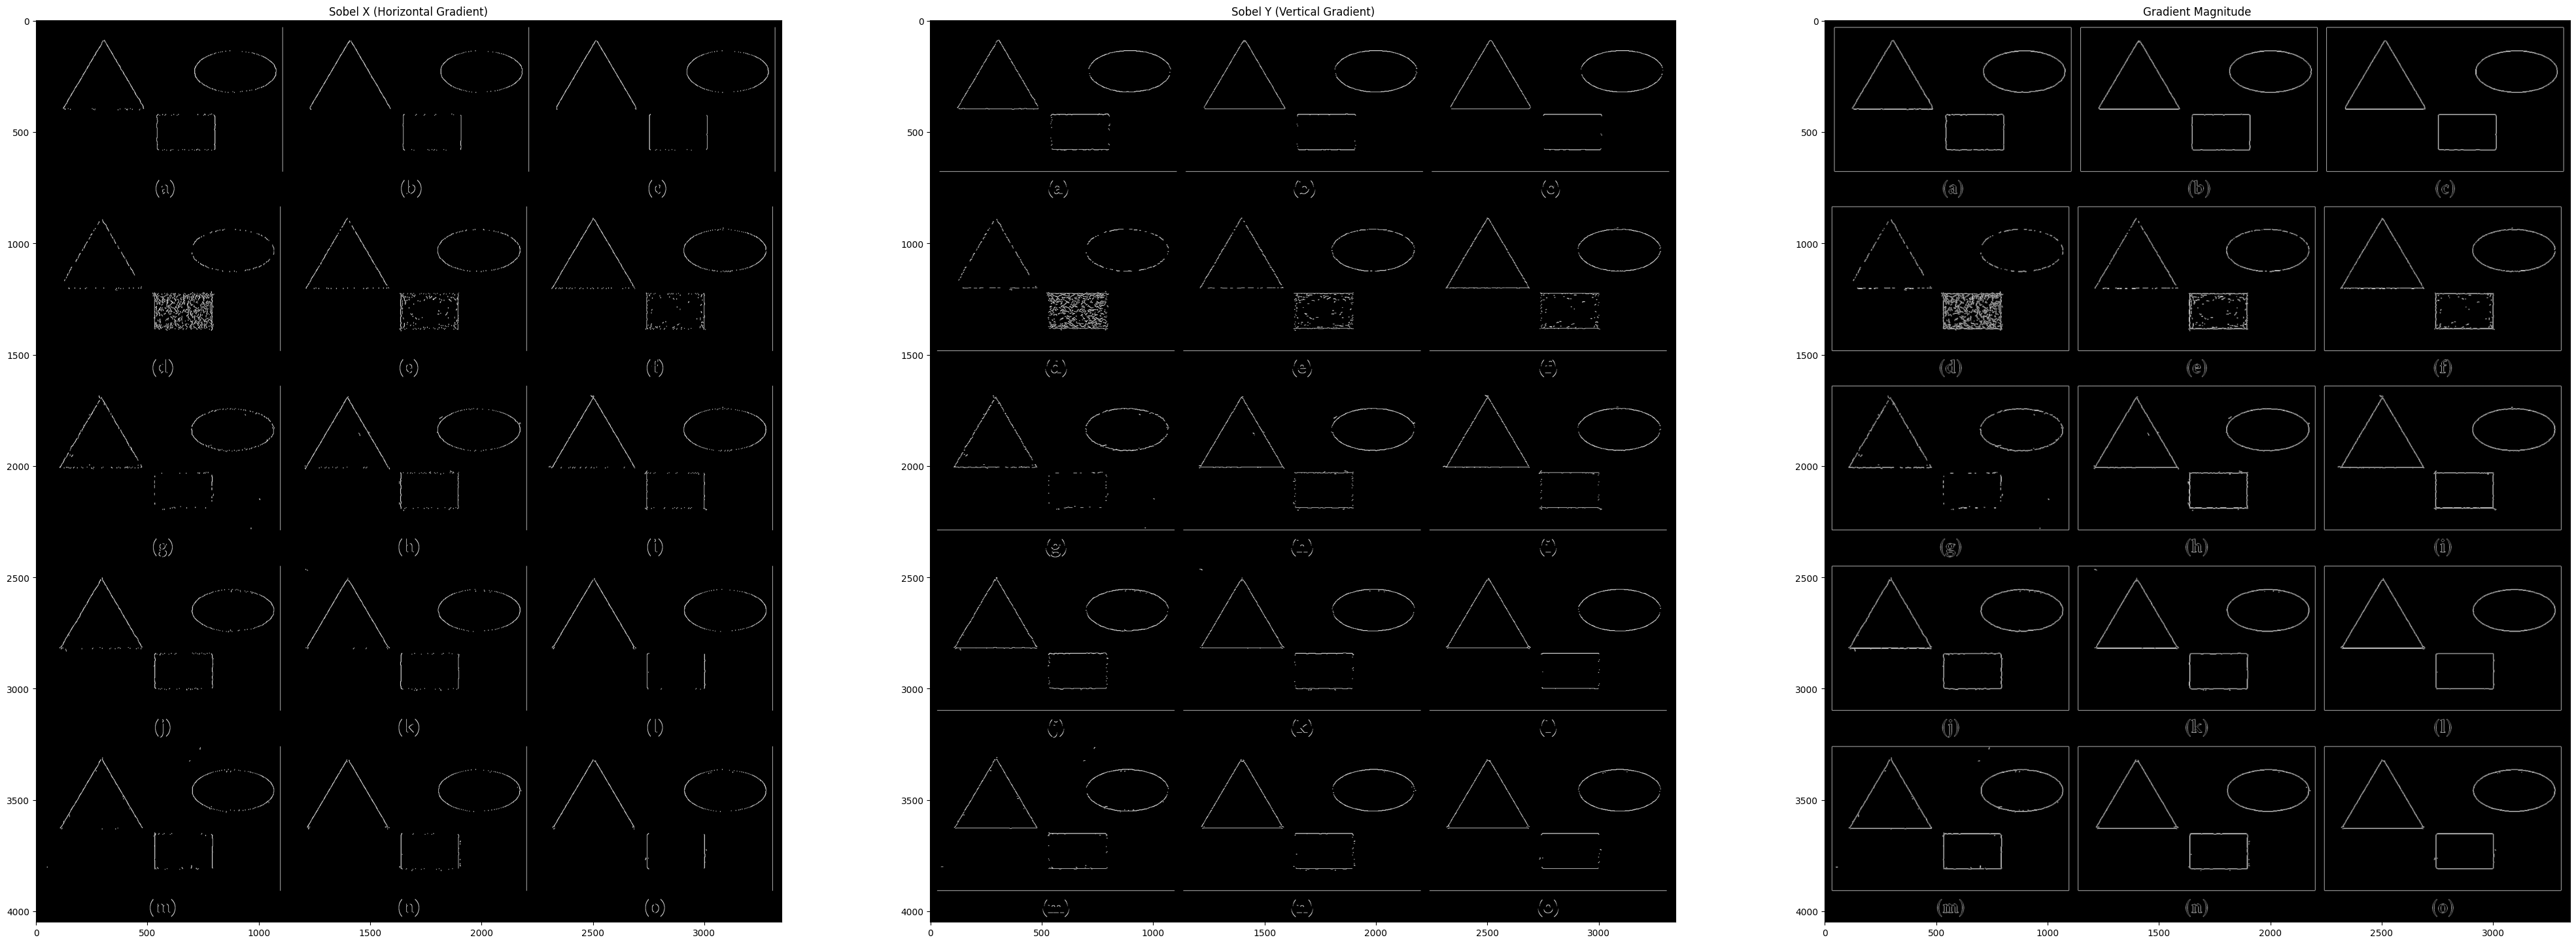

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread(r"C:\Users\ind81\Downloads\Sobel_1.png")
sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
magnitude = np.uint8(magnitude)
plt.figure(figsize=(50,30))
plt.subplot(1,3,1)
plt.title("Sobel X (Horizontal Gradient)")
plt.imshow(sobel_x, cmap='gray')
plt.subplot(1,3,2)
plt.title("Sobel Y (Vertical Gradient)")
plt.imshow(sobel_y, cmap='gray')
plt.subplot(1,3,3)
plt.title("Gradient Magnitude")
plt.imshow(magnitude, cmap='gray')
plt.show()

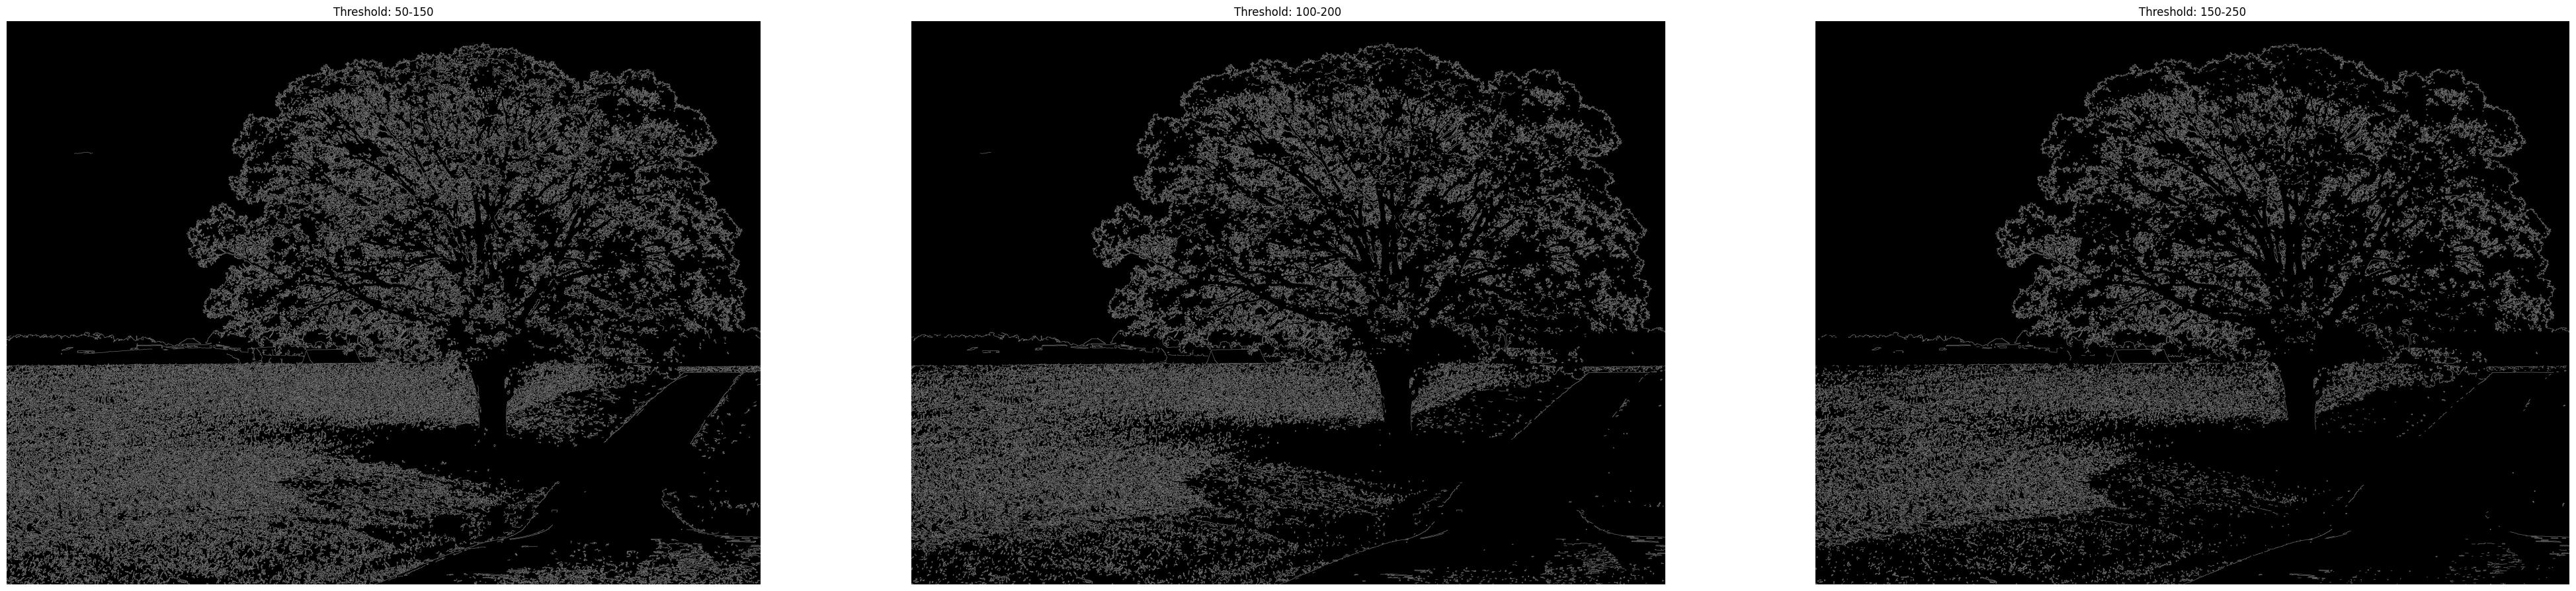

In [15]:
import cv2
import matplotlib.pyplot as plt
img = cv2.imread(r"C:\Users\ind81\Downloads\Canny_1.jpg")
blur = cv2.GaussianBlur(img, (5,5), 0)
edges1 = cv2.Canny(blur, 50, 150)
edges2 = cv2.Canny(blur, 100, 200)
edges3 = cv2.Canny(blur, 150, 250)
plt.figure(figsize=(50,30))
plt.subplot(1,3,1)
plt.title("Threshold: 50-150")
plt.imshow(edges1, cmap='gray')
plt.axis('off')
plt.subplot(1,3,2)
plt.title("Threshold: 100-200")
plt.imshow(edges2, cmap='gray')
plt.axis('off')
plt.subplot(1,3,3)
plt.title("Threshold: 150-250")
plt.imshow(edges3, cmap='gray')
plt.axis('off')
plt.show()

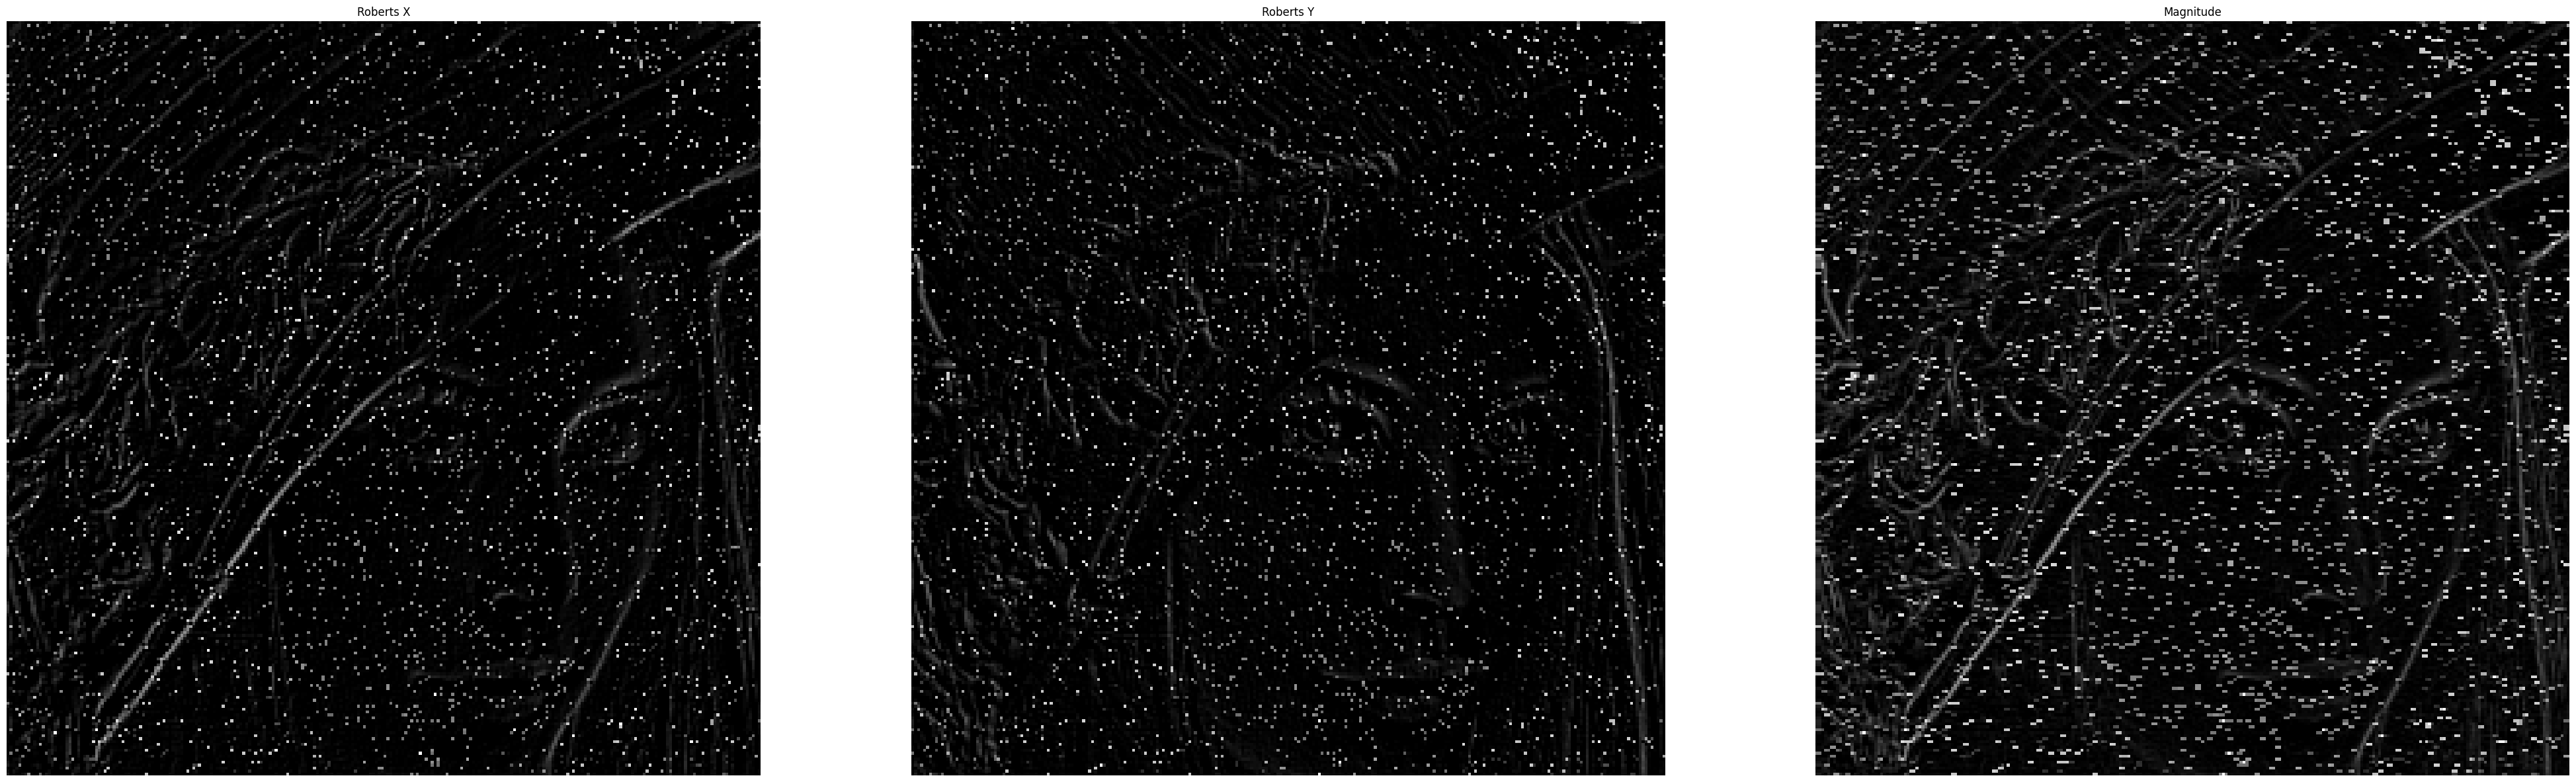

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread(r"C:\Users\ind81\Downloads\Roberts_1.png")
kernel_x = np.array([[1, 0],[0, -1]])
kernel_y = np.array([[0, 1],[-1, 0]])
roberts_x = cv2.filter2D(img, -1, kernel_x)
roberts_y = cv2.filter2D(img, -1, kernel_y)
magnitude = np.sqrt(roberts_x.astype(float)**2 + roberts_y.astype(float)**2)
magnitude = np.uint8(magnitude)
plt.figure(figsize=(50,30))
plt.subplot(1,3,1)
plt.title("Roberts X")
plt.imshow(roberts_x, cmap='gray')
plt.axis('off')
plt.subplot(1,3,2)
plt.title("Roberts Y")
plt.imshow(roberts_y, cmap='gray')
plt.axis('off')
plt.subplot(1,3,3)
plt.title("Magnitude")
plt.imshow(magnitude, cmap='gray')
plt.axis('off')
plt.show()

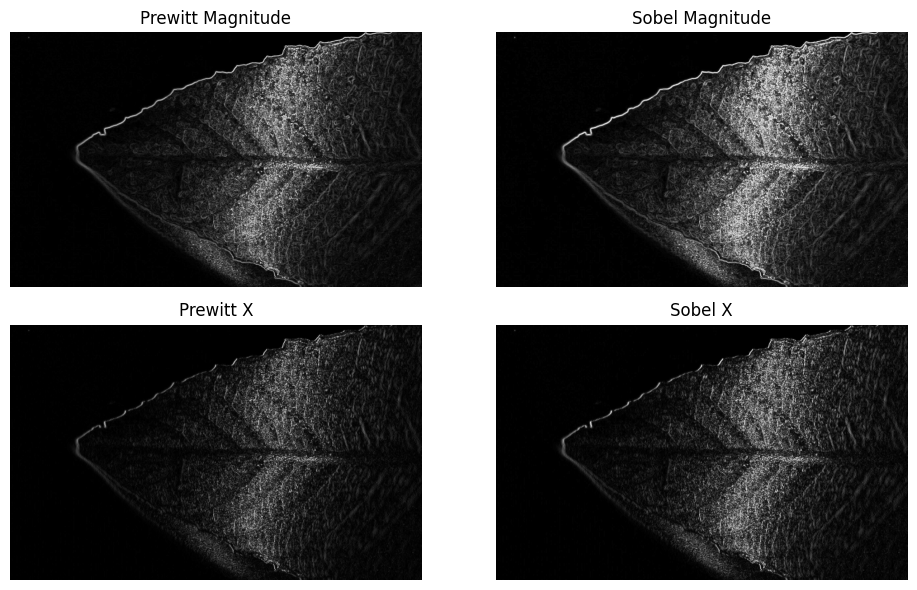

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def apply_operator(img, kernel_x, kernel_y, name):
    grad_x = cv2.filter2D(img, cv2.CV_64F, kernel_x)
    grad_y = cv2.filter2D(img, cv2.CV_64F, kernel_y)
    magnitude = cv2.magnitude(grad_x, grad_y)
    magnitude = cv2.convertScaleAbs(magnitude)
    return magnitude, grad_x, grad_y
img = cv2.imread( r"C:\Users\ind81\Downloads\Prewitt_2.jpg")
if img is None:
    print(f"Error: Image not found at {img_path}")
    exit()
prewitt_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float32)
prewitt_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], dtype=np.float32)
pmag, px, py = apply_operator(img, prewitt_x, prewitt_y, 'Prewitt')
sx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
smag = cv2.magnitude(sx, sy)
smag = cv2.convertScaleAbs(smag)
images = [(pmag, 'Prewitt Magnitude'),(smag, 'Sobel Magnitude'),(px, 'Prewitt X'),(sx, 'Sobel X')]
plt.figure(figsize=(10, 6))
for i, (image, title) in enumerate(images, 1):
    plt.subplot(2, 2, i)
    plt.title(title)
    if 'Magnitude' not in title:
        image = cv2.convertScaleAbs(image)
    plt.imshow(image, cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()